In [1]:
import numpy as np
import finesse
import matplotlib.pyplot as plt
from utils.finesse_base import base_kat
from finesse.knm import Map
from finesse.utilities.maps import circular_aperture
from utils.sim import finesse_sim
from GNN.GNN_run import model_to_nx_port, run_GNN

/home/xuesi.ma/.conda/envs/ligoopt/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Check if the subspace created by ITM ROC and ETM ROC are different

In [2]:
ITM_ROC_nominal = -1934
ETM_ROC_nominal = 2245


ITM_ROC_List = np.linspace(ITM_ROC_nominal - 500, ITM_ROC_nominal + 500, 25)
ETM_ROC_List = np.linspace(ETM_ROC_nominal - 500, ETM_ROC_nominal + 500, 25)

find_q_kat = base_kat.deepcopy()
find_q_kat.parse(f"bp q_value ITM.p1.i prop=q")
q_value = find_q_kat.run()["q_value"]
print(q_value)

(-1834.203538874628+427.8399492372375j)


#### Finesse simulation of this subspace

In [3]:
kat_sim = base_kat.deepcopy()
# Fixed the q value to the nominal q value
kat_sim.parse(f"gauss fixed_q_value ITM.p1.i q={q_value}")
# Add a circular aperture
x = y = np.linspace(-0.17, 0.17, 100)
kat_sim.ETM.surface_map = Map(x, y, amplitude=circular_aperture(x,y,0.17))

power_list = []
for ITM_roc in ITM_ROC_List:
    for ETM_roc in ETM_ROC_List:
        kat_sim.ITM.Rc = ITM_roc
        kat_sim.ETM.Rc = ETM_roc
        
        
        if not kat_sim.cavArm.is_stable:
            power_list.append(0)
            continue
        
        try:
            ref_power = kat_sim.run("""Series(
                            run_locks(max_iterations=100000,),
                            noxaxis(),
                            )""")
        except finesse.exceptions.LostLock as e:
            print(f"lock failed: {e}")
            power_list.append(0)
            continue

  
        power_list.append(ref_power["noxaxis"]["p_ETM_p1_i"])

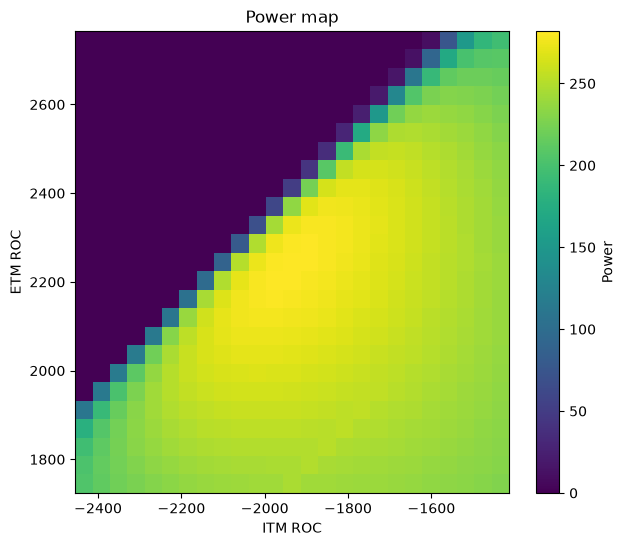

In [15]:
# Reshape the flattened power list into a 2D grid
power_grid = np.array(power_list).reshape(len(ETM_ROC_List), len(ITM_ROC_List))

# Create the mesh for plotting
X, Y = np.meshgrid(ITM_ROC_List, ETM_ROC_List)

plt.figure(figsize=(7, 6))
plt.pcolormesh(X, Y, power_grid, cmap='viridis', shading='auto')
plt.colorbar(label='Power')
plt.xlabel('ITM ROC')
plt.ylabel('ETM ROC')
plt.title('Power map')
plt.savefig("Figures/power_map_finesse.png")
plt.show()

In [5]:
print(power_list)

[np.float64(204.3491455732731), np.float64(213.41733240786544), np.float64(220.37074165291727), np.float64(225.78037908649355), np.float64(230.0308331070481), np.float64(233.36054453301395), np.float64(235.98612240105524), np.float64(238.00138407389167), np.float64(239.51792453848086), np.float64(240.61095259496545), np.float64(241.34050301178468), np.float64(241.75825885045091), np.float64(245.9718500417556), np.float64(241.77360995076882), np.float64(241.42725632068448), np.float64(240.8830933820069), np.float64(240.15388325118727), np.float64(239.25315121423603), np.float64(238.1923002010358), np.float64(236.9818793719812), np.float64(235.6274804075174), np.float64(234.1359092150522), np.float64(232.51794123948193), np.float64(230.76757718660758), np.float64(228.89311847959212), np.float64(202.1969192200376), np.float64(213.96488881534086), np.float64(222.54434127628164), np.float64(228.97129440487828), np.float64(233.84709912762975), np.float64(237.56346243495068), np.float64(240.3

#### GNN simulation of the subspace

In [6]:
kat_GNN = base_kat.deepcopy()
model_path = "GNN/models/power_predictor_ligoParams_loss_fixed_gat10_kan5.pt"
pd_name = "ETM.p1.i"
power_list_GNN = []

for ITM_roc in ITM_ROC_List:
    for ETM_roc in ETM_ROC_List:
        kat_GNN.ITM.Rc = ITM_roc
        kat_GNN.ETM.Rc = ETM_roc

        name, powers = run_GNN(kat_GNN, model_path)

        index = name.index(pd_name)
        ref_power = powers[index]

        power_list_GNN.append(ref_power)

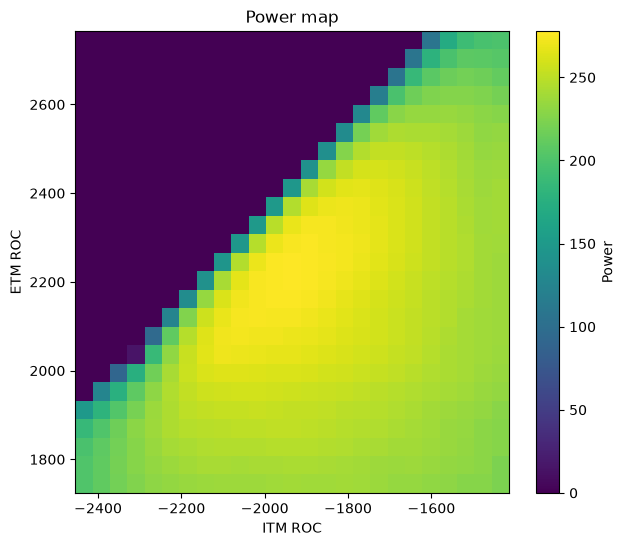

In [14]:
# Reshape the flattened power list into a 2D grid
power_grid_GNN = np.array(power_list_GNN).reshape(len(ETM_ROC_List), len(ITM_ROC_List))

# Create the mesh for plotting
X, Y = np.meshgrid(ITM_ROC_List, ETM_ROC_List)

plt.figure(figsize=(7, 6))
plt.pcolormesh(X, Y, power_grid_GNN, cmap='viridis', shading='auto')
plt.colorbar(label='Power')
plt.xlabel('ITM ROC')
plt.ylabel('ETM ROC')
plt.title('Power map')
plt.savefig('Figures/power_map_GNN.png')
plt.show()

In [8]:
print(power_list_GNN)

[201.42230224609375, 210.37208557128906, 218.47152709960938, 225.79261779785156, 230.52035522460938, 233.08743286132812, 234.839599609375, 235.7540740966797, 236.90748596191406, 236.88819885253906, 237.53814697265625, 238.69293212890625, 239.16990661621094, 238.8244171142578, 238.6483612060547, 239.0030975341797, 237.87484741210938, 235.9656219482422, 234.38851928710938, 233.8155517578125, 232.31639099121094, 230.43580627441406, 227.8201141357422, 227.98504638671875, 223.01844787597656, 201.51132202148438, 210.48602294921875, 219.82569885253906, 227.60995483398438, 233.2132568359375, 236.453125, 239.1326904296875, 241.42678833007812, 241.91812133789062, 241.0077667236328, 241.57040405273438, 242.06954956054688, 242.47776794433594, 242.80307006835938, 241.5398712158203, 240.56573486328125, 239.55087280273438, 237.6032257080078, 236.47361755371094, 236.69407653808594, 234.57232666015625, 232.99334716796875, 232.1697998046875, 229.24569702148438, 222.6791229248047, 197.8293914794922, 209.